In [86]:
import copernicusmarine
import rioxarray as riox
from openexr_numpy import imwrite

ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_arc_phy_my_nextsim_P1D-m')

INFO - 2026-04-23T12:02:52Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:

INFO - 2026-04-23T12:03:13Z - Selected dataset version: "202411"
INFO - 2026-04-23T12:03:13Z - Selected dataset part: "default"


In [87]:
da = ds['sithick']
daily_2023 = da.sel(time=slice('2023-08','2024-07'), latitude=slice(55,91))
daily_2023

<xarray.DataArray 'sithick' (time: 366, latitude: 1168, longitude: 12000)> Size: 41GB
dask.array<getitem, shape=(366, 1168, 12000), dtype=float64, chunksize=(50, 512, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-08-01 2023-08-02 ... 2024-07-31
  * latitude   (latitude) float64 9kB 55.02 55.05 55.08 ... 89.97 90.0 90.03
  * longitude  (longitude) float64 96kB -180.0 -180.0 -179.9 ... 179.9 180.0
Attributes:
    cell_methods:   time: mean (interval: 6 hours) area: mean
    long_name:      Sea Ice Thickness
    regrid_method:  bilinear
    standard_name:  sea_ice_thickness
    units:          m

In [ ]:
chunks = 365//50
value_count = 0
for chunk in range(chunks+1): 
    this_chunk = daily_2023[50*chunk:50*(chunk+1)].load()
    for i in range(50):
        this_slice = this_chunk[i]
        imwrite(f'2023_float16/timestep_{str(value_count).zfill(3)}.exr', this_slice.data.astype('float16'), channel_names="R")
        value_count += 1
    print(f"Chunk {chunk} complete")

Chunk 0 complete
Chunk 1 complete
Chunk 2 complete
Chunk 3 complete
Chunk 4 complete
Chunk 5 complete
Chunk 6 complete


IndexError: index 16 is out of bounds for axis 0 with size 16

In [52]:
da = da.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
da = da.rio.write_crs("EPSG:4326")
da = da.load()

In [90]:
def add_exr_extension(folder_path: str, dry_run: bool = True) -> None:
    """
    Adds '.exr' extension to every file in a folder that doesn't already have it.
 
    Args:
        folder_path: Path to the folder containing the files.
        dry_run: If True, only prints what would be renamed without doing it.
    """
    folder = os.path.abspath(folder_path)
 
    if not os.path.isdir(folder):
        print(f"Error: '{folder}' is not a valid directory.")
        return
 
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
 
    if not files:
        print("No files found in the folder.")
        return
 
    print(f"{'[DRY RUN] ' if dry_run else ''}Processing {len(files)} file(s) in '{folder}':\n")
 
    renamed = 0
    skipped = 0
 
    for filename in files:
        if filename.endswith(".exr"):
            print(f"  SKIP    {filename}  (already has .exr)")
            skipped += 1
            continue
 
        old_path = os.path.join(folder, filename)
        new_name = filename + ".exr"
        new_path = os.path.join(folder, new_name)
 
        print(f"  RENAME  {filename}  →  {new_name}")
 
        if not dry_run:
            os.rename(old_path, new_path)
 
        renamed += 1
 
    print(f"\n{'Would rename' if dry_run else 'Renamed'} {renamed} file(s), skipped {skipped}.")
    if dry_run:
        print("Run with dry_run=False to apply changes.")

add_exr_extension('2023_float16', dry_run=False)

Processing 366 file(s) in '/home/jpoehls/Documents/Ocean Viz/2023_float16':

  RENAME  timestep_083  →  timestep_083.exr
  RENAME  timestep_167  →  timestep_167.exr
  RENAME  timestep_050  →  timestep_050.exr
  RENAME  timestep_261  →  timestep_261.exr
  RENAME  timestep_051  →  timestep_051.exr
  RENAME  timestep_205  →  timestep_205.exr
  RENAME  timestep_013  →  timestep_013.exr
  RENAME  timestep_277  →  timestep_277.exr
  RENAME  timestep_288  →  timestep_288.exr
  RENAME  timestep_245  →  timestep_245.exr
  RENAME  timestep_004  →  timestep_004.exr
  RENAME  timestep_107  →  timestep_107.exr
  RENAME  timestep_183  →  timestep_183.exr
  RENAME  timestep_066  →  timestep_066.exr
  RENAME  timestep_357  →  timestep_357.exr
  RENAME  timestep_007  →  timestep_007.exr
  RENAME  timestep_285  →  timestep_285.exr
  RENAME  timestep_186  →  timestep_186.exr
  RENAME  timestep_057  →  timestep_057.exr
  RENAME  timestep_266  →  timestep_266.exr
  RENAME  timestep_046  →  timestep_046.exr

In [55]:
from tqdm import tqdm
for i in tqdm(range(da.shape[0])):
    sub_array = da[i]
    sub_array = sub_array.rio.reproject("EPSG:3413")
    imwrite(f'Daily/2003_ice_{str(i).zfill(3)}.exr', sub_array.data.astype('float32'), channel_names="R")
    

100%|██████████| 178/178 [06:06<00:00,  2.06s/it]


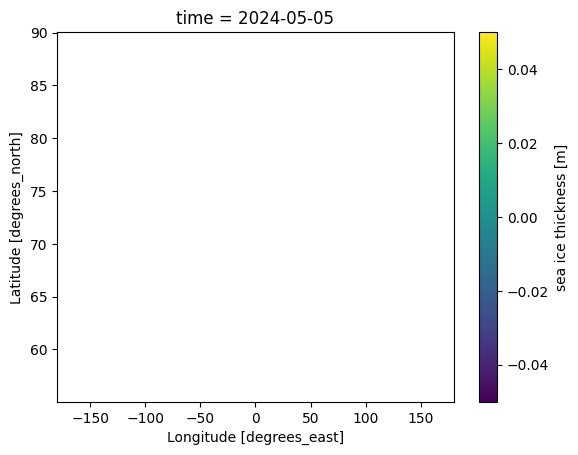

In [59]:
da[200].plot()


In [50]:
temp.rio.reproject("EPSG:3413")

<xarray.DataArray 'sea_ice_thickness' (y: 2573, x: 2542)> Size: 52MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(2573, 2542))
Coordinates:
  * y            (y) float64 21kB 3.902e+06 3.899e+06 ... -3.898e+06 -3.901e+06
  * x            (x) float64 20kB -3.854e+06 -3.851e+06 ... 3.852e+06 3.855e+06
    time         datetime64[ns] 8B 2023-10-18
    spatial_ref  int64 8B 0
Attributes:
    ancillary_variables:  sea_ice_thickness_uncertainty status_flag quality_flag
    comment:              derived by optimal interpolation
    long_name:            sea ice thickness
    regrid_method:        bilinear
    standard_name:        sea_ice_thickness
    units:                m

In [34]:
imwrite(f'daily_test.exr', temp.data.astype('float32'), channel_names="R")

In [4]:
da = ds['sea_ice_thickness']
da = da.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
da = da.rio.write_crs("EPSG:4326")
da = da.sel(latitude=slice(55,100)).load()
reproj = da.rio.reproject("EPSG:3413")

In [5]:
year_max = reproj.groupby(reproj.time.dt.year).max()

In [85]:
ds

<xarray.Dataset> Size: 15TB
Dimensions:         (time: 11688, latitude: 1336, longitude: 12000)
Coordinates:
  * time            (time) datetime64[ns] 94kB 1993-01-01 ... 2024-12-31
  * latitude        (latitude) float64 11kB 49.98 50.01 50.04 ... 90.0 90.03
  * longitude       (longitude) float64 96kB -180.0 -180.0 ... 179.9 180.0
Data variables:
    si_ridge_ratio  (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    siage           (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    sialb           (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    siconc          (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    siconc_my       (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    siconc_young    (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    sisnthick       (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    sithick         (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    vxsi            (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
    vysi            (time, latitude, longitude) float64 1TB dask.array<chunksize=(50, 512, 2048), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.6
    contact:                   servicedesk.cmems@mercator-ocean.eu
    credit:                    E.U. Copernicus Marine Service Information (CM...
    field_date:                2023-12-31
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    references:                https://marine.copernicus.eu/
    source:                    neXtSIM model fields
    title:                     Arctic sea ice reanalysis
    copernicusmarine_version:  2.4.0

In [19]:
from openexr_numpy import imread, imwrite

for i in range(year_max.shape[0]):
    slice = year_max[i]
    array = slice.data
    year_str = slice.year.data
    imwrite(f'Outputs/{year_str}.exr', array, channel_names="R")

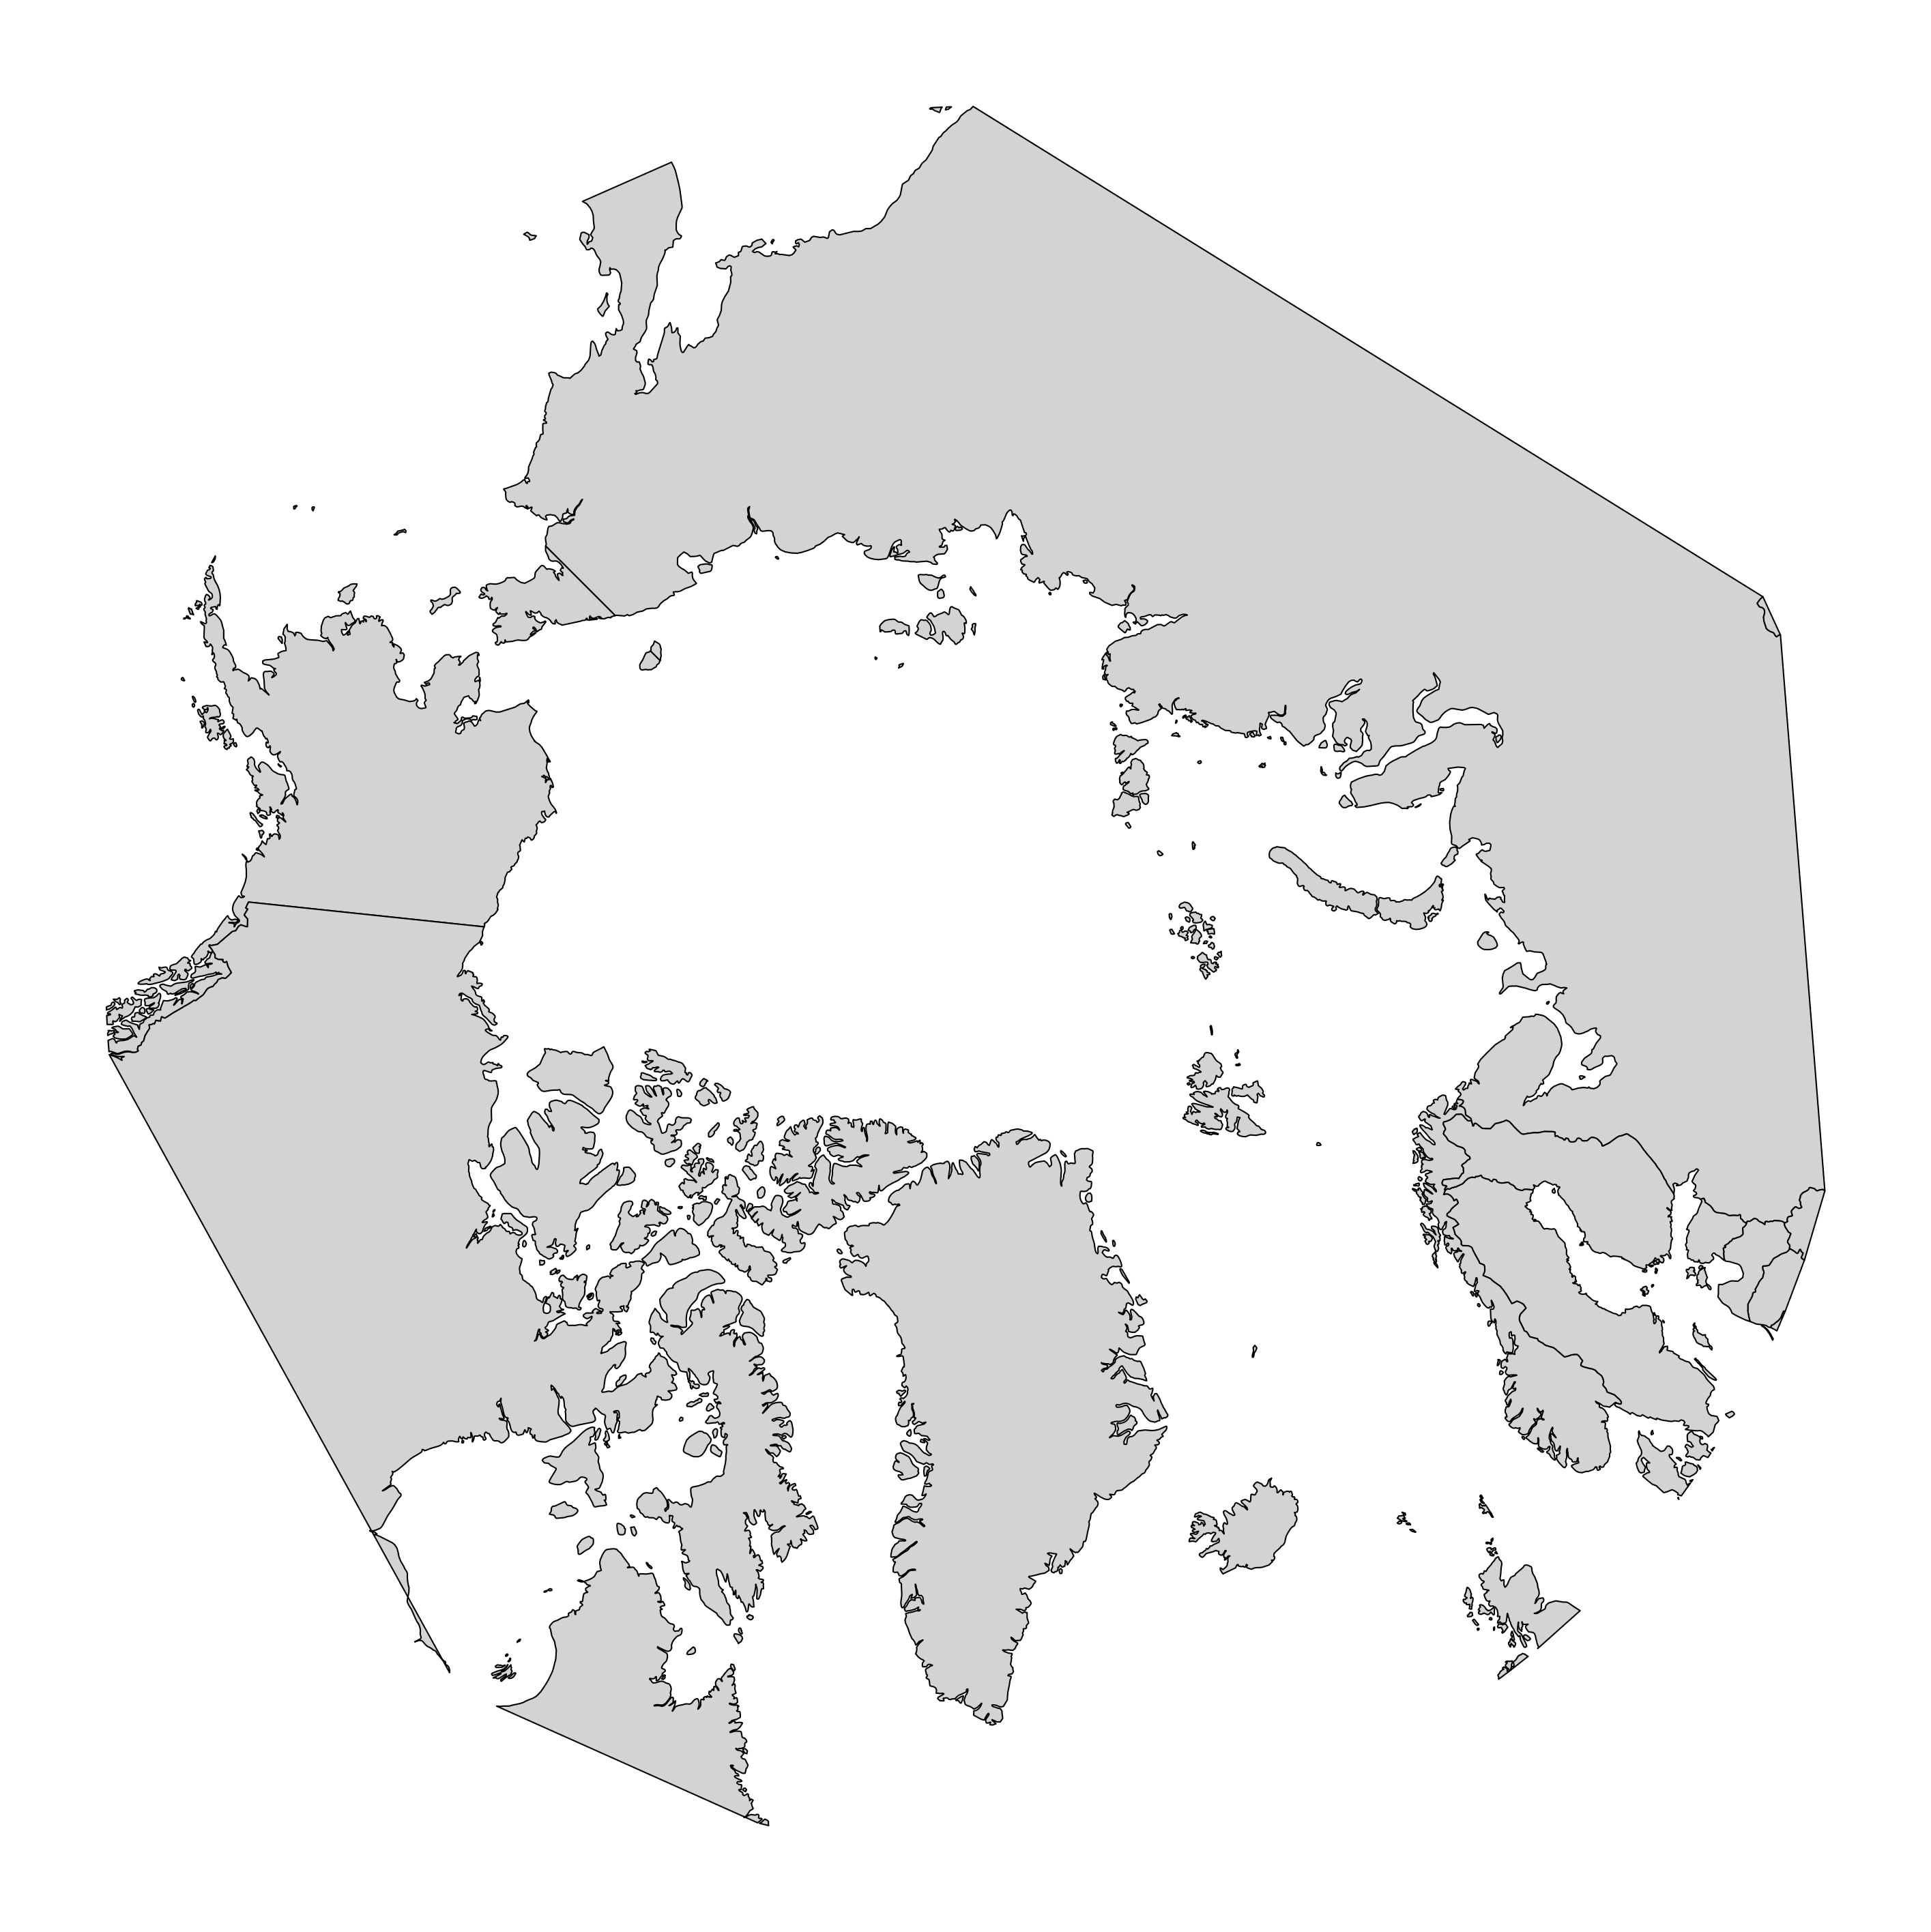

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
world = gpd.read_file(url)

# Clip to Arctic latitudes first (in WGS84), then reproject
arctic = world.clip_by_rect(-180, 55, 180, 90)  # lon, lat bounds
arctic_3413 = arctic.to_crs("EPSG:3413")

fig, ax = plt.subplots(figsize=(12, 12), dpi=300)
arctic_3413.plot(ax=ax, edgecolor='black', linewidth=0.5, facecolor='lightgray')
ax.set_aspect('equal')
ax.axis('off')
plt.savefig('output_3413.png', dpi=300, bbox_inches='tight')
plt.show()
